In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [14]:
#Các thông số vật lý của hệ con lắc 
L1 = 1.0 #Chiều dài của dây treo con lắc 1 (đơn vị: mét)
L2 = 1.0 #Chiều dài của dây treo con lắc 2 (đơn vị: mét)
L3 = 1.0 #Chiều dài của dây treo con lắc 3 (đơn vị: mét)
m1 = 5.0 #Khối lượng của con lắc 1 (đơn vị: kg)
m2 = 2.0 #Khối lượng của con lắc 2 (đơn vị: kg)
m3 = 1.0 #Khối lượng của con lắc 3 (đơn vị: kg)
g = 9.81 #Gia tốc trọng trường (đơn vị: m/s^2)
end_time = 10 #Khoảng thời gian xét sự chuyển động của hệ con lắc kép
t = np.linspace(0, end_time, 50000) #Tạo mảng thời gian

In [15]:
def triple_pendulum_ode_function(
        state, t, 
        L1, L2, L3, 
        m1, m2, m3, 
        g):
    theta1, omega1, theta2, omega2, theta3, omega3 = state

    # ===== góc =====
    d12 = theta1 - theta2
    d13 = theta1 - theta3
    d23 = theta2 - theta3

    # ===== sin cos =====
    sin12, cos12 = np.sin(d12), np.cos(d12)
    sin13, cos13 = np.sin(d13), np.cos(d13)
    sin23, cos23 = np.sin(d23), np.cos(d23)

    eps = 1e-6
    
    M11 = (m1+m2+m3)*L1**2
    M12 = (m2+m3)*L1*L2*cos12
    M13 = m3*L1*L3*cos13

    M21 = M12
    M22 = (m2+m3)*L2**2
    M23 = m3*L2*L3*cos23

    M31 = M13
    M32 = M23
    M33 = m3*L3**2

    M = np.array([
        [M11,M12,M13],
        [M21,M22,M23],
        [M31,M32,M33]
    ])

    G = np.array([
        -(m1+m2+m3)*g*L1*np.sin(theta1),
        -(m2+m3)*g*L2*np.sin(theta2),
        -m3*g*L3*np.sin(theta3)
    ])

    C = np.array([
        -(m2+m3)*L1*L2*sin12*omega2**2
        -m3*L1*L3*sin13*omega3**2,

        (m2+m3)*L1*L2*sin12*omega1**2
        -m3*L2*L3*sin23*omega3**2,

        m3*L1*L3*sin13*omega1**2
        +m3*L2*L3*sin23*omega2**2
    ])

    ddtheta = np.linalg.solve(M,G+C)
   
    return [
        omega1,ddtheta[0],
        omega2,ddtheta[1],
        omega3,ddtheta[2]
    ]

In [16]:
import numpy as np
from scipy.integrate import odeint

initial_state_tp = [
    np.pi/6, 0,
    np.pi/6, 0,
    np.pi/6, 0
]

tp_solution = odeint(
    triple_pendulum_ode_function,
    initial_state_tp,
    t,
    args=(L1, L2, L3, m1, m2, m3, g)
)

# Trích theta
theta1_numerical = tp_solution[:, 0]
theta2_numerical = tp_solution[:, 2]
theta3_numerical = tp_solution[:, 4]

print("theta1[:5]:", theta1_numerical[:5])
print("theta2[:5]:", theta2_numerical[:5])
print("theta3[:5]:", theta3_numerical[:5])

# ===== STACK =====


y_numerical = torch.tensor(
    np.stack([
        theta1_numerical,
        theta2_numerical,
        theta3_numerical
    ], axis=1),
    dtype=torch.float32
) 

# ===== TRAINING DATA =====
t_torch = torch.tensor(t, dtype=torch.float32).view(-1, 1)

x_data_tp = t_torch[:10000:1000]
y_data_tp = y_numerical[:10000:1000]

print("x_data_tp:", x_data_tp.shape)
print("y_data_tp:", y_data_tp.shape)
print(y_data_tp)
print(np.max(np.abs(theta1_numerical)))
print(np.max(np.abs(theta2_numerical)))
print(np.max(np.abs(theta3_numerical)))


print("max omega1 =", np.max(np.abs(tp_solution[:,1])))
print("max omega2 =", np.max(np.abs(tp_solution[:,3])))
print("max omega3 =", np.max(np.abs(tp_solution[:,5])))


theta1[:5]: [0.52359878 0.52359868 0.52359838 0.52359789 0.52359721]
theta2[:5]: [0.52359878 0.52359878 0.52359878 0.52359878 0.52359878]
theta3[:5]: [0.52359878 0.52359878 0.52359878 0.52359878 0.52359878]
x_data_tp: torch.Size([10, 1])
y_data_tp: torch.Size([10, 3])
tensor([[ 0.5236,  0.5236,  0.5236],
        [ 0.4300,  0.5191,  0.5235],
        [ 0.2003,  0.4546,  0.5180],
        [-0.0435,  0.2383,  0.4638],
        [-0.1992, -0.1087,  0.2482],
        [-0.2548, -0.4217, -0.2223],
        [-0.2603, -0.5706, -0.8278],
        [-0.2413, -0.6000, -1.2893],
        [-0.1941, -0.5306, -1.4676],
        [-0.1264, -0.3566, -1.3100]])
0.5235987755982988
0.7077422528751592
1.5229806512332473
max omega1 = 1.4426137876613963
max omega2 = 1.8569334711969008
max omega3 = 4.812759559026283


In [17]:
def triple_pendulum_physics_residuals(
    theta1,dtheta1,
    theta2,dtheta2,
    theta3,dtheta3,
    ddtheta1,ddtheta2,ddtheta3,
    L1,L2,L3,
    m1,m2,m3,
    g
):

    r1 = (
        (m1+m2+m3)*L1**2*ddtheta1
        +(m2+m3)*L1*L2*torch.cos(theta1-theta2)*ddtheta2
        +m3*L1*L3*torch.cos(theta1-theta3)*ddtheta3

        +(m2+m3)*L1*L2*torch.sin(theta1-theta2)*dtheta2**2
        +m3*L1*L3*torch.sin(theta1-theta3)*dtheta3**2

        +(m1+m2+m3)*g*L1*torch.sin(theta1)
    )

    r2 = (
        (m2+m3)*L2**2*ddtheta2
        +(m2+m3)*L1*L2*torch.cos(theta1-theta2)*ddtheta1
        +m3*L2*L3*torch.cos(theta2-theta3)*ddtheta3

        -(m2+m3)*L1*L2*torch.sin(theta1-theta2)*dtheta1**2
        +m3*L2*L3*torch.sin(theta2-theta3)*dtheta3**2

        +(m2+m3)*g*L2*torch.sin(theta2)
    )

    r3 = (
        m3*L3**2*ddtheta3
        +m3*L1*L3*torch.cos(theta1-theta3)*ddtheta1
        +m3*L2*L3*torch.cos(theta2-theta3)*ddtheta2

        -m3*L1*L3*torch.sin(theta1-theta3)*dtheta1**2
        -m3*L2*L3*torch.sin(theta2-theta3)*dtheta2**2

        +m3*g*L3*torch.sin(theta3)
    )
    

    return r1,r2,r3

In [18]:
def triple_pendulum_energy(theta1, dtheta1,
                           theta2, dtheta2,
                           theta3, dtheta3,
                           L1, L2, L3,
                           m1, m2, m3,
                           g):

    kinetic = (
        0.5*(m1+m2+m3)*L1**2*dtheta1**2
        + 0.5*(m2+m3)*L2**2*dtheta2**2
        + 0.5*m3*L3**2*dtheta3**2
        + (m2+m3)*L1*L2*dtheta1*dtheta2*torch.cos(theta1-theta2)
        + m3*L1*L3*dtheta1*dtheta3*torch.cos(theta1-theta3)
        + m3*L2*L3*dtheta2*dtheta3*torch.cos(theta2-theta3)
    )

    potential = (
        -(m1+m2+m3)*g*L1*torch.cos(theta1)
        -(m2+m3)*g*L2*torch.cos(theta2)
        -m3*g*L3*torch.cos(theta3)
    )

    return kinetic + potential

In [19]:
class FCN(nn.Module):

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()

        activation = nn.Tanh

        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )

        self.fch = nn.Sequential(*[
            nn.Sequential(
                nn.Linear(N_HIDDEN, N_HIDDEN),
                activation()
            )
            for _ in range(N_LAYERS - 1)
        ])

        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):

        x = torch.cat([
            x,
            x**2,
            torch.sin(x),
            torch.cos(x),
            torch.sin(2 * x),
            torch.cos(2 * x),
            torch.sin(3*x),
            torch.cos(3*x),
        ], dim=1)

        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)

        return x

In [20]:
def plot_result_triple_pendulum(
    x,
    theta1_numerical,
    theta2_numerical,
    theta3_numerical,
    yh_theta1,
    yh_theta2,
    yh_theta3,
    x_data,
    y_data=None,
):
    plt.figure(figsize=(12, 6))

    
    x_np = x.detach().cpu().numpy()

    # nhân ngược lại về đơn vị rad
    yh1 = yh_theta1.detach().cpu().numpy() 
    yh2 = yh_theta2.detach().cpu().numpy() 
    yh3 = yh_theta3.detach().cpu().numpy() 

    if y_data is not None:
        x_data_np = x_data.detach().cpu().numpy()
        y_data_np = y_data.detach().cpu().numpy() 
        idx = np.random.choice(len(x_data_np), min(2000, len(x_data_np)), replace=False)

    sampling_step = 400
    step = 5 
    
    x_sampled = x_np[::sampling_step]

    # theta1
    plt.subplot(1,3,1)
    plt.plot(x_sampled,
             theta1_numerical[::sampling_step],
             'o', markersize=3, color='red', alpha=0.9)

    plt.plot(x_np[::step], yh1[::step], color='blue')
    

    if y_data is not None:
        plt.scatter(x_data_np[idx], y_data_np[idx,0],color='green', s=20)

    plt.title("Theta1")
    plt.grid()

    # theta2
    plt.subplot(1,3,2)
    plt.plot(x_sampled,
             theta2_numerical[::sampling_step],
             'o', markersize=3, color='red', alpha=0.9)

    plt.plot(x_np[::step], yh2[::step], color='blue')

    if y_data is not None:
        plt.scatter(x_data_np[idx], y_data_np[idx,1], color='green', s=20)

    plt.title("Theta2")
    plt.grid()

    # theta3
    plt.subplot(1,3,3)
    plt.plot(x_sampled,
             theta3_numerical[::sampling_step],
             'o', markersize= 3, color='red', alpha=0.9)


    plt.plot(x_np[::step], yh3[::step], color='blue')

    if y_data is not None:
        plt.scatter(x_data_np[idx], y_data_np[idx,2], color='green', s=20)

    plt.title("Theta3")
    plt.grid()

    plt.subplots_adjust(wspace=0.25, hspace=0.25)

In [ ]:
# ===== DEVICE =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== DATA TO DEVICE =====
x_physics = torch.linspace(0, end_time, 1000).view(-1,1).to(device)
x_physics.requires_grad_(True)

x_data_tp = x_data_tp.to(device)
y_data_tp = y_data_tp.to(device)

# ===== MODEL =====
dp_model = FCN(8, 3, 128, 6).to(device)
optimizer_dp = torch.optim.Adam(dp_model.parameters(), lr=5e-4)
files_tp = []
# ===== LOSS WEIGHTS =====
lambda1 = 10
lambda2 = 100
lambda3 = 500
lambda4 = 0.1


# Lists to store loss values for plotting
loss_data_history = []
loss_physics_history = []
loss_ic_history = []
loss_energy_history = []
total_loss_history = []
iterations_history = []

# ===== TRAIN LOOP =====
target_loss= 1e-2
max_epochs = 50000

i = 0

while i < max_epochs:
    optimizer_dp.zero_grad()

    # ===== PHYSICS =====
    theta_pred_physics = dp_model(x_physics)

    theta1 = theta_pred_physics[:, 0:1]
    theta2 = theta_pred_physics[:, 1:2]
    theta3 = theta_pred_physics[:, 2:3]

    dtheta1 = torch.autograd.grad(theta1, x_physics, torch.ones_like(theta1), create_graph=True)[0]
    d2theta1 = torch.autograd.grad(dtheta1, x_physics, torch.ones_like(dtheta1), create_graph=True)[0]

    dtheta2 = torch.autograd.grad(theta2, x_physics, torch.ones_like(theta2), create_graph=True)[0]
    d2theta2 = torch.autograd.grad(dtheta2, x_physics, torch.ones_like(dtheta2), create_graph=True)[0]

    dtheta3 = torch.autograd.grad(theta3, x_physics, torch.ones_like(theta3), create_graph=True)[0]
    d2theta3 = torch.autograd.grad(dtheta3, x_physics, torch.ones_like(dtheta3), create_graph=True)[0]

    r1, r2, r3 = triple_pendulum_physics_residuals(
        theta1, dtheta1,
        theta2, dtheta2,
        theta3, dtheta3,
        d2theta1, d2theta2, d2theta3,
        L1, L2, L3,
        m1, m2, m3,
        g
    )

    loss_physics = (
        torch.mean((r1/(m1+m2+m3))**2) 
        + torch.mean((r2/(m2+m3))**2)
        + torch.mean((r3/m3)**2)
    )

    # ===== DATA =====
    theta_pred_data = dp_model(x_data_tp)

    loss_data = torch.mean(
        (theta_pred_data[:,0:1] - y_data_tp[:,0:1])**2 +
        (theta_pred_data[:,1:2] - y_data_tp[:,1:2])**2 +
        (theta_pred_data[:,2:3] - y_data_tp[:,2:3])**2
    )

    # ===== INITIAL CONDITION =====
    x0 = torch.tensor([[0.0]], dtype=torch.float32, requires_grad=True).to(device)
    y0 = dp_model(x0)

    dtheta1_0 = torch.autograd.grad(y0[:,0:1], x0, torch.ones_like(y0[:,0:1]), create_graph=True)[0]
    dtheta2_0 = torch.autograd.grad(y0[:,1:2], x0, torch.ones_like(y0[:,1:2]), create_graph=True)[0]
    dtheta3_0 = torch.autograd.grad(y0[:,2:3], x0, torch.ones_like(y0[:,2:3]), create_graph=True)[0]

    loss_ic = (
    (y0[:,0] - initial_state_tp[0])**2 +
    (y0[:,1] - initial_state_tp[2])**2 +
    (y0[:,2] - initial_state_tp[4])**2 +
    (dtheta1_0 - initial_state_tp[1])**2 +
    (dtheta2_0 - initial_state_tp[3])**2 +
    (dtheta3_0 - initial_state_tp[5])**2
    ).mean()

    # ===== ENERGY =====
    energy_pred = triple_pendulum_energy(
        theta1, dtheta1,
        theta2, dtheta2,
        theta3, dtheta3,
        L1, L2, L3,
        m1, m2, m3,
        g
        )

    energy_initial = energy_pred[0:1].detach()

    loss_energy = torch.mean((energy_pred - energy_initial)**2)

    # ===== TOTAL LOSS =====
    loss = lambda1*loss_data + lambda2*loss_physics + lambda3*loss_ic + lambda4*loss_energy

    # ===== NAN GUARD =====
    if torch.isnan(loss):
        print(f" NaN detected at iter {i}")
        break

    loss.backward()

    optimizer_dp.step()

    # ===== print ====
    if loss.item() <= target_loss:
        print(f"\nTarget reached at iteration {i+1}")
        print(f"Total Loss = {loss.item():.6e}")
        break
    if (i + 1) % 1000 == 0:
        print(f"Iteration {i+1}, Loss_data: {loss_data.item():.6f}, Loss_physics: {loss_physics.item():.6f}, Losss_ic: {loss_ic.item():.6f}, Loss_energy: {loss_energy.item():.6f}, Total Loss: {loss.item():.6f}")

        # Store loss values
        iterations_history.append(i + 1)
        loss_data_history.append(loss_data.item())
        loss_physics_history.append(loss_physics.item())
        loss_ic_history.append(loss_ic.item())
        loss_energy_history.append(loss_energy.item())
        total_loss_history.append(loss.item())

    # ===== PLOT =====
    yh_full = dp_model(t_torch.to(device)).detach().cpu()

    yh_theta1 = yh_full[:, 0]
    yh_theta2 = yh_full[:, 1]
    yh_theta3 = yh_full[:, 2]

    plot_result_triple_pendulum(
        t_torch.cpu(),
        theta1_numerical,
        theta2_numerical,
        theta3_numerical,
        yh_theta1,
        yh_theta2,
        yh_theta3,
        x_data_tp.cpu(),
        y_data_tp.cpu()
    )
    
    if (i + 1) % 5000 == 0:
            plt.show()
    else:
            plt.close("all") 
    i += 1
            


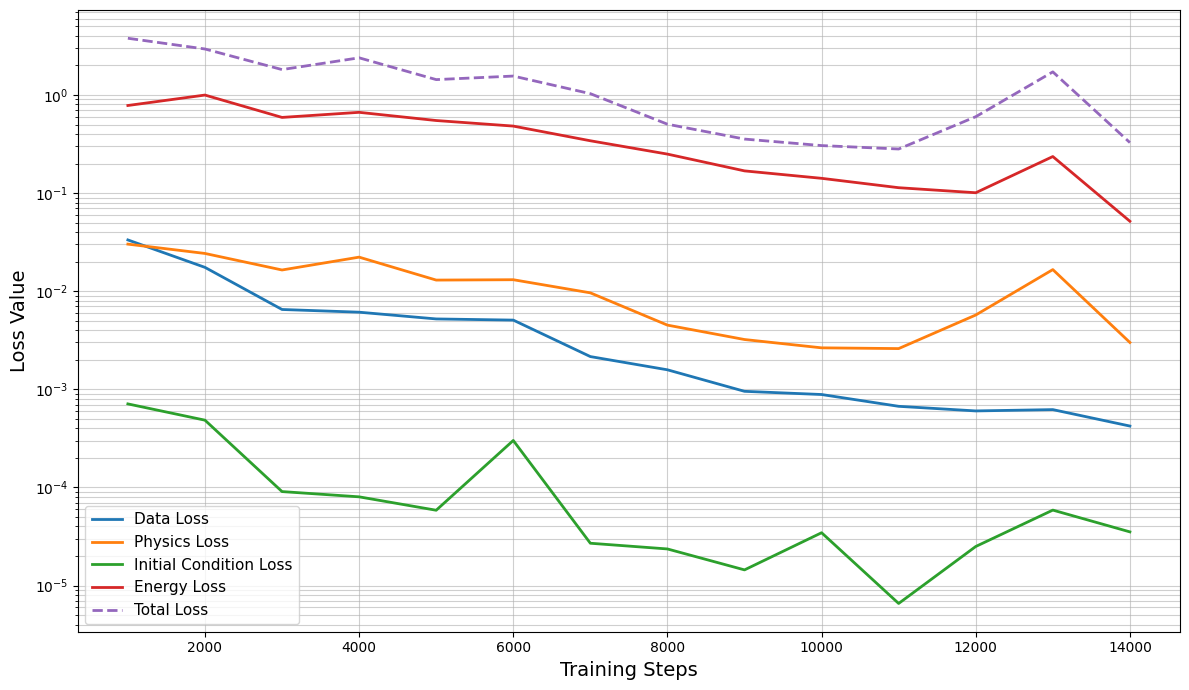

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# training steps
# Use the actual iteration numbers collected during training
training_steps_actual = np.array(iterations_history)

plt.figure(figsize=(12, 7))

# từng thành phần loss
plt.plot(
    training_steps_actual,
    loss_data_history,
    label='Data Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_physics_history,
    label='Physics Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_ic_history,
    label='Initial Condition Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_energy_history,
    label='Energy Loss',
    linewidth=2
)

# loss tổng
plt.plot(
    training_steps_actual,
    total_loss_history,
    '--',
    label='Total Loss',
    linewidth=2
)

plt.xlabel('Training Steps', fontsize=14)
plt.ylabel('Loss Value', fontsize=14)

# log scale rất quan trọng
plt.yscale('log')

plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# ===== SAVE CHECKPOINT (TRIPLE PENDULUM) =====
save_path = "triple_pendulum_pinn.pt"

torch.save({
    # ===== model =====
    "model_state_dict": dp_model.state_dict(),
    "optimizer_state_dict": optimizer_dp.state_dict(),

    # ===== training info =====
    "epoch": i,
    "loss": loss.item(),

    # ===== loss history =====
    "loss_data_history": loss_data_history,
    "loss_physics_history": loss_physics_history,
    "loss_ic_history": loss_ic_history,
    "loss_energy_history": loss_energy_history,
    "total_loss_history": total_loss_history,
    "iterations_history": iterations_history,

    # ===== system params =====
    "L": [L1, L2, L3],
    "m": [m1, m2, m3],
    "g": g,

    # ===== initial condition =====
    "initial_state": initial_state_tp,

    # ===== training data =====
    "x_data": x_data_tp.cpu(),
    "y_data": y_data_tp.cpu(),

}, save_path)

print("Saved model to", save_path)

Saved model to triple_pendulum_pinn.pt


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =========================
# 1. MODEL
# =========================

class FCN(torch.nn.Module):
    def __init__(self, input_size, output_size, hidden_size, num_layers):
        super().__init__()

        layers = [
            torch.nn.Linear(input_size, hidden_size),
            torch.nn.Tanh()
        ]

        for _ in range(num_layers - 1):
            layers += [
                torch.nn.Linear(hidden_size, hidden_size),
                torch.nn.Tanh()
            ]

        layers.append(torch.nn.Linear(hidden_size, output_size))

        self.network = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# =========================
# 2. LOAD TRAINED MODEL
# =========================

model = FCN(
    input_size=7,
    output_size=3,
    hidden_size=128,
    num_layers=6
)

model.load_state_dict(
    torch.load(
        "triple_pendulum_pinn.pt",
        map_location="cpu"
    )
)

model.eval()

print("Model loaded!")

RuntimeError: Error(s) in loading state_dict for FCN:
	Missing key(s) in state_dict: "network.0.weight", "network.0.bias", "network.2.weight", "network.2.bias", "network.4.weight", "network.4.bias", "network.6.weight", "network.6.bias", "network.8.weight", "network.8.bias", "network.10.weight", "network.10.bias", "network.12.weight", "network.12.bias". 
	Unexpected key(s) in state_dict: "model_state_dict", "optimizer_state_dict", "epoch", "loss", "loss_data_history", "loss_physics_history", "loss_ic_history", "loss_energy_history", "total_loss_history", "iterations_history", "L", "m", "g", "initial_state", "x_data", "y_data". 

In [ ]:
# =========================
# TIME
# =========================

t = np.linspace(0, 15, 1000)

t_tensor = torch.tensor(
    t,
    dtype=torch.float32
).reshape(-1, 1)


# =========================
# PINN PREDICTION
# =========================

with torch.no_grad():

    # Nếu model của m chỉ nhận t
    # thì dùng dòng này:
    pred = model(t_tensor)

theta1 = pred[:, 0].numpy()
theta2 = pred[:, 1].numpy()
theta3 = pred[:, 2].numpy()